# CA industrial petroleum CO2 emissions Forecasting Analysis

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings("ignore")

# Time series and diagnostics
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
import statsmodels.api as sm

# ML and evaluation
from sklearn.linear_model import LassoCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Explainability
import shap

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [4]:
# Load EIA CO2 emissions data from JSON lines
records = []
with open('../data/EMISS.txt', 'r') as file:
    for line in file:
        entry = json.loads(line)
        if entry['series_id'] == 'EMISS.CO2-TOTV-IC-PE-CA.A':
            records = entry['data']
            break

# Create dataframe and resample to monthly
df = pd.DataFrame(records, columns=['Year', 'Emissions'])
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
df = df.sort_values('Year').set_index('Year')
df = df.resample('MS').ffill()


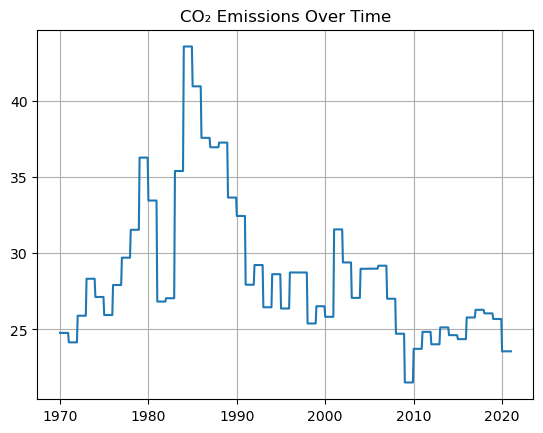

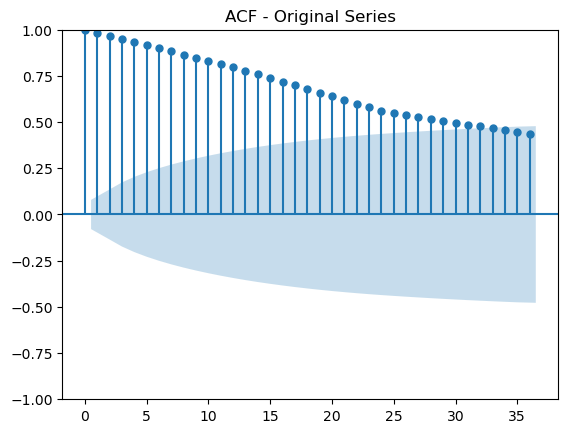

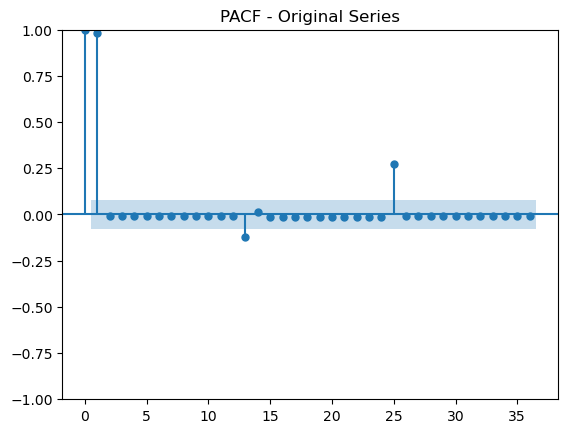

ADF Statistic: -2.1095, p-value: 0.2407


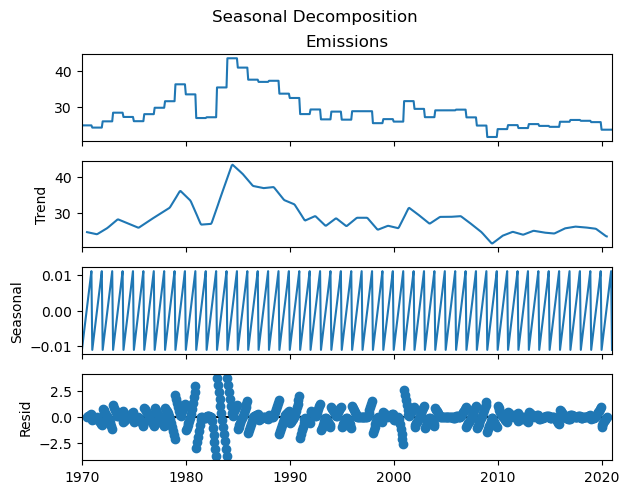

In [5]:
# EDA and Stationarity Check

# Time series plot
plt.plot(df.index, df['Emissions'])
plt.title('CO₂ Emissions Over Time')
plt.grid(True)
plt.show()

# ACF and PACF
plot_acf(df['Emissions'], lags=36)
plt.title('ACF - Original Series')
plt.show()

plot_pacf(df['Emissions'], lags=36)
plt.title('PACF - Original Series')
plt.show()

# ADF test
adf_stat, p_val, *_ = adfuller(df['Emissions'])
print(f"ADF Statistic: {adf_stat:.4f}, p-value: {p_val:.4f}")
# p > 0.05 → nonstationary → SARIMA with d=1 is appropriate

# Seasonal decomposition
seasonal_decompose(df['Emissions'], model='additive', period=12).plot()
plt.suptitle("Seasonal Decomposition", y=1.02)
plt.show()
# Seasonal component is flat → no monthly seasonality



## Modelling Part 1 (SARIMA)
- SARIMA (pre-feature engineering-- models autocorrelation, seasonality, differencing interanally.


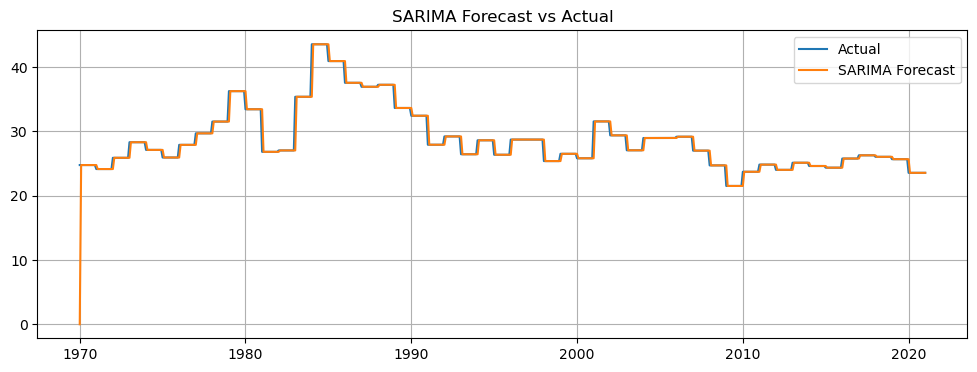

In [7]:
# Fit SARIMA model with differencing, no seasonal component (based on diagnostics)
sarima_model = SARIMAX(
    df['Emissions'],
    order=(1, 1, 1),  # AR(1), differencing, MA(1)
    seasonal_order=(0, 0, 0, 0),  # no seasonal pattern detected
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_results = sarima_model.fit(disp=False, maxiter=100)

# Generate in-sample predictions from SARIMA
df['SARIMA_Forecast'] = sarima_results.predict(start=0, end=len(df)-1)

# Plot SARIMA predictions vs actual
plt.figure(figsize=(12, 4))
plt.plot(df['Emissions'], label='Actual')
plt.plot(df['SARIMA_Forecast'], label='SARIMA Forecast')
plt.legend()
plt.grid(True)
plt.title('SARIMA Forecast vs Actual')
plt.show()


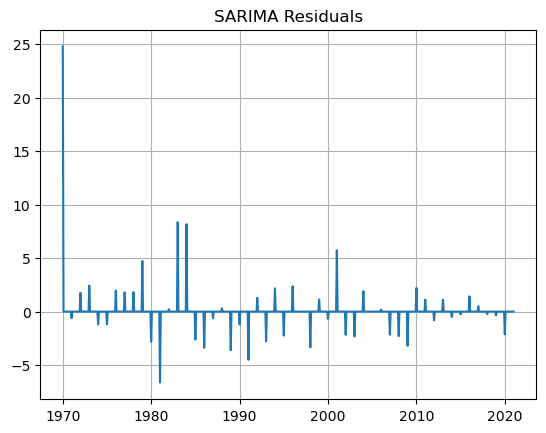

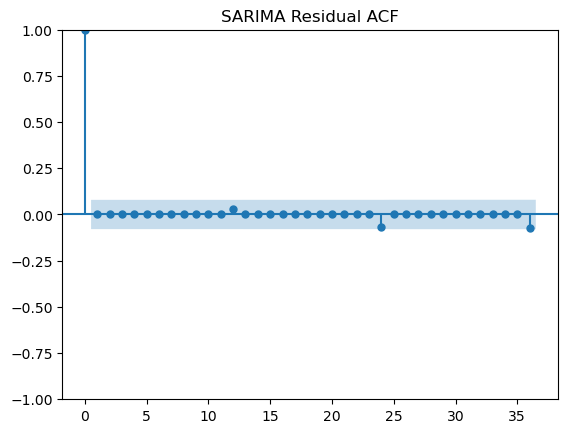

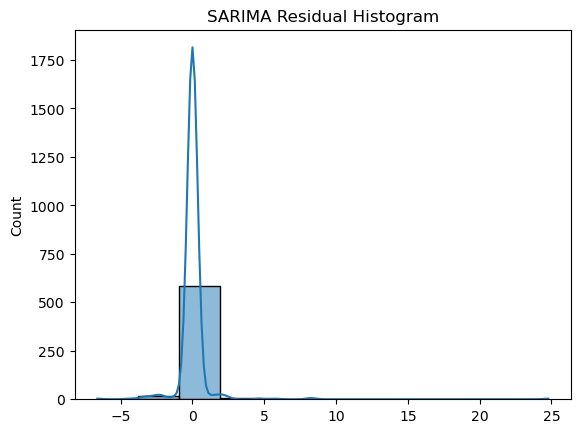

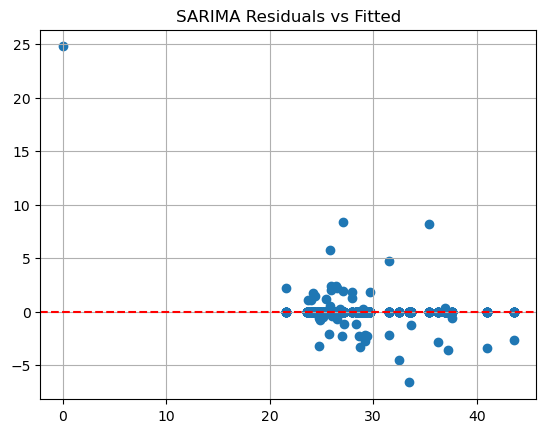

SARIMA Ljung-Box p-value: 0.9999992005959331


In [8]:
# Residual diagnostics
resid_sarima = df['Emissions'] - df['SARIMA_Forecast']

plt.plot(resid_sarima)
plt.title("SARIMA Residuals")
plt.grid(True)
plt.show()

plot_acf(resid_sarima.dropna(), lags=36)
plt.title("SARIMA Residual ACF")
plt.show()

sns.histplot(resid_sarima.dropna(), kde=True)
plt.title("SARIMA Residual Histogram")
plt.show()

plt.scatter(df['SARIMA_Forecast'], resid_sarima)
plt.axhline(0, color='red', linestyle='--')
plt.title("SARIMA Residuals vs Fitted")
plt.grid(True)
plt.show()

print("SARIMA Ljung-Box p-value:",
      acorr_ljungbox(resid_sarima.dropna(), lags=[12], return_df=True)['lb_pvalue'].values[0])


## Feature Engineering
- Lag1
- Lag12
- Lag24
- MA3
- MA6
- Month

In [9]:
df['Lag1'] = df['Emissions'].shift(1)
df['Lag24'] = df['Emissions'].shift(24)
df['MA3'] = df['Emissions'].rolling(3).mean()
df['MA6'] = df['Emissions'].rolling(6).mean()
df['Month'] = df.index.month
df.dropna(inplace=True)

## Modelling Part 2 (Ridge, Gradient Boosting, SHAP, Lasso)
- Ridge Regression
- Gradient Boosting, SHAP, and diagnostics
- Lasso Regression + Diagnostics

In [10]:
# Train Test Split

train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

X_train = train[['Lag1', 'Lag24', 'MA3', 'MA6', 'Month']]
y_train = train['Emissions']
X_test = test[['Lag1', 'Lag24', 'MA3', 'MA6', 'Month']]
y_test = test['Emissions']

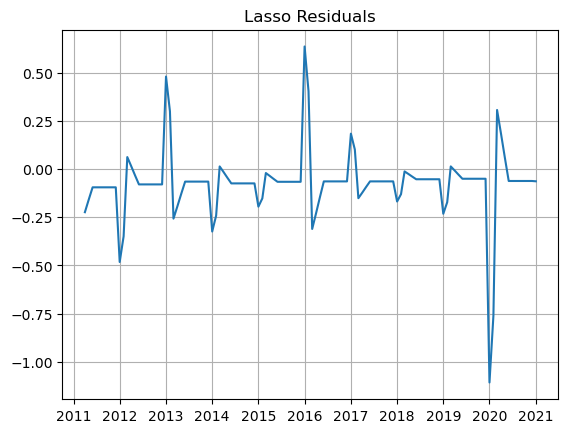

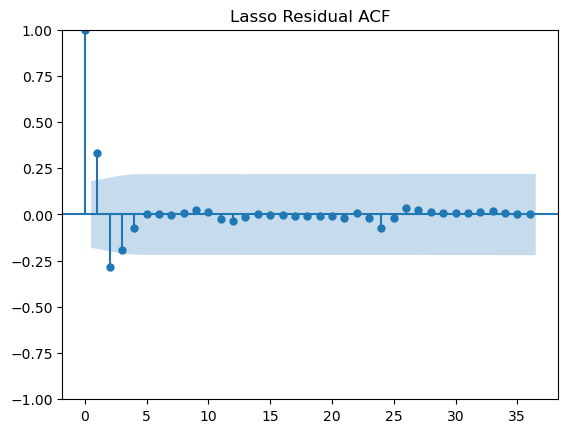

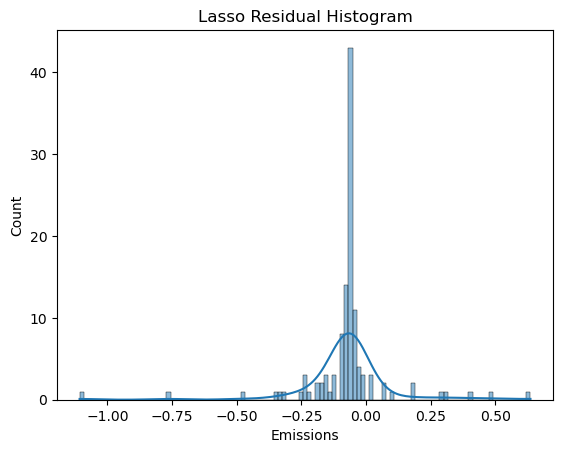

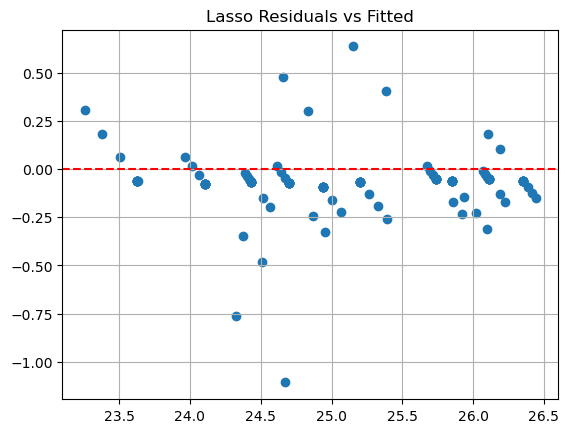

Lasso Ljung-Box p: 0.004704608649158184
Lasso Breusch-Pagan p: 0.3317166601103759


In [11]:
# LASSO Regression + Diagnostics

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso = LassoCV(cv=TimeSeriesSplit(n_splits=5))
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)
resid_lasso = y_test - lasso_pred

# Residual plots
plt.plot(resid_lasso)
plt.title("Lasso Residuals")
plt.grid(True)
plt.show()

plot_acf(resid_lasso, lags=36)
plt.title("Lasso Residual ACF")
plt.show()

sns.histplot(resid_lasso, kde=True)
plt.title("Lasso Residual Histogram")
plt.show()

plt.scatter(lasso_pred, resid_lasso)
plt.axhline(0, color='red', linestyle='--')
plt.title("Lasso Residuals vs Fitted")
plt.grid(True)
plt.show()

print("Lasso Ljung-Box p:",
      acorr_ljungbox(resid_lasso, lags=[12], return_df=True)['lb_pvalue'].values[0])

X_const = sm.add_constant(lasso_pred)
print("Lasso Breusch-Pagan p:",
      het_breuschpagan(resid_lasso, X_const)[3])


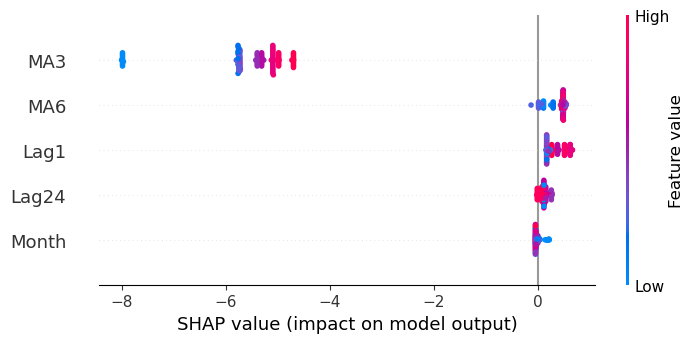

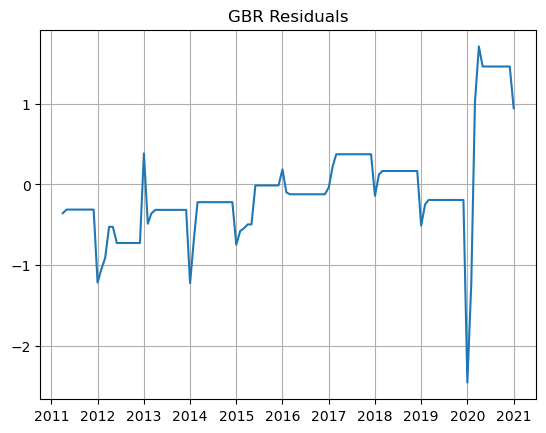

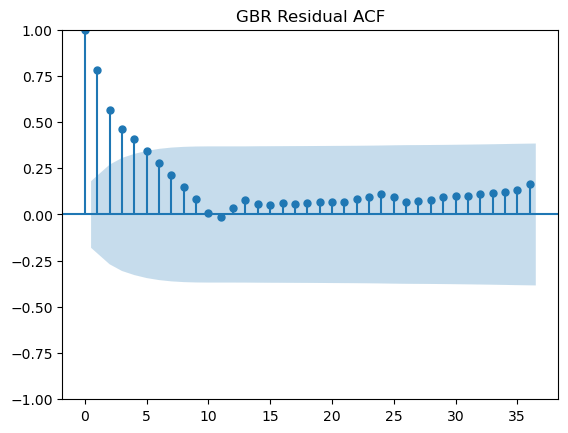

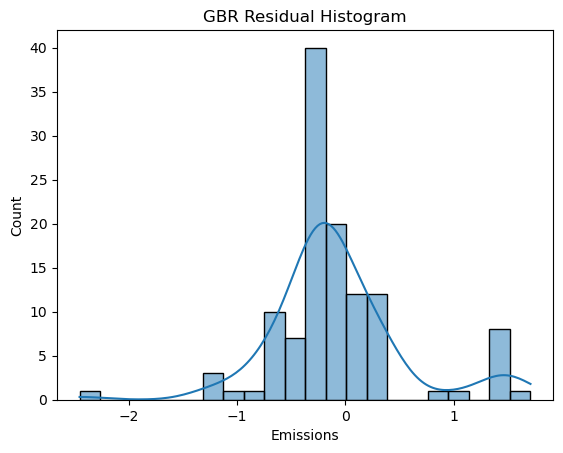

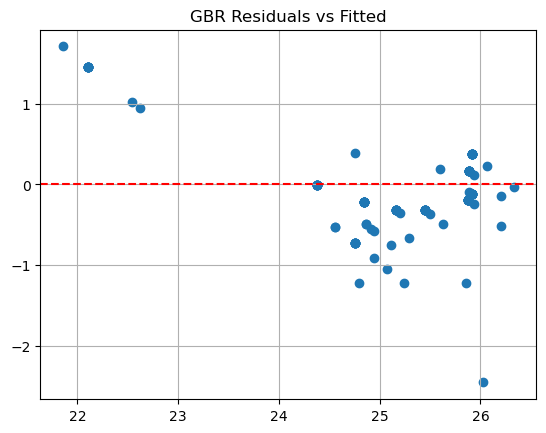

In [13]:
# Gradient Boosting, SHAP, Diagnostics

# Fit Gradient Boosting Regressor
gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)

# SHAP Explanation for interpretability
explainer = shap.Explainer(gbr)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)

# Residual diagnostics
resid_gbr = y_test - gbr_pred
plt.plot(resid_gbr)
plt.title("GBR Residuals")
plt.grid(True)
plt.show()

plot_acf(resid_gbr, lags=36)
plt.title("GBR Residual ACF")
plt.show()

sns.histplot(resid_gbr, kde=True)
plt.title("GBR Residual Histogram")
plt.show()

plt.scatter(gbr_pred, resid_gbr)
plt.axhline(0, color='red', linestyle='--')
plt.title("GBR Residuals vs Fitted")
plt.grid(True)
plt.show()


## Model Evaluation (RMSE, MAE, MAPE, MBE)

In [15]:
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    mbe = np.mean(y_pred - y_true)
    print(f"\n{name} Evaluation:")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  MAE:  {mae:.3f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  MBE:  {mbe:.3f}")

evaluate_model("SARIMA", df['Emissions'], df['SARIMA_Forecast'])
evaluate_model("Lasso", y_test, lasso_pred)
evaluate_model("GBR", y_test, gbr_pred)



SARIMA Evaluation:
  RMSE: 0.831
  MAE:  0.180
  MAPE: 0.61%
  MBE:  0.001

Lasso Evaluation:
  RMSE: 0.192
  MAE:  0.120
  MAPE: 0.48%
  MBE:  0.074

GBR Evaluation:
  RMSE: 0.626
  MAE:  0.445
  MAPE: 1.82%
  MBE:  0.077


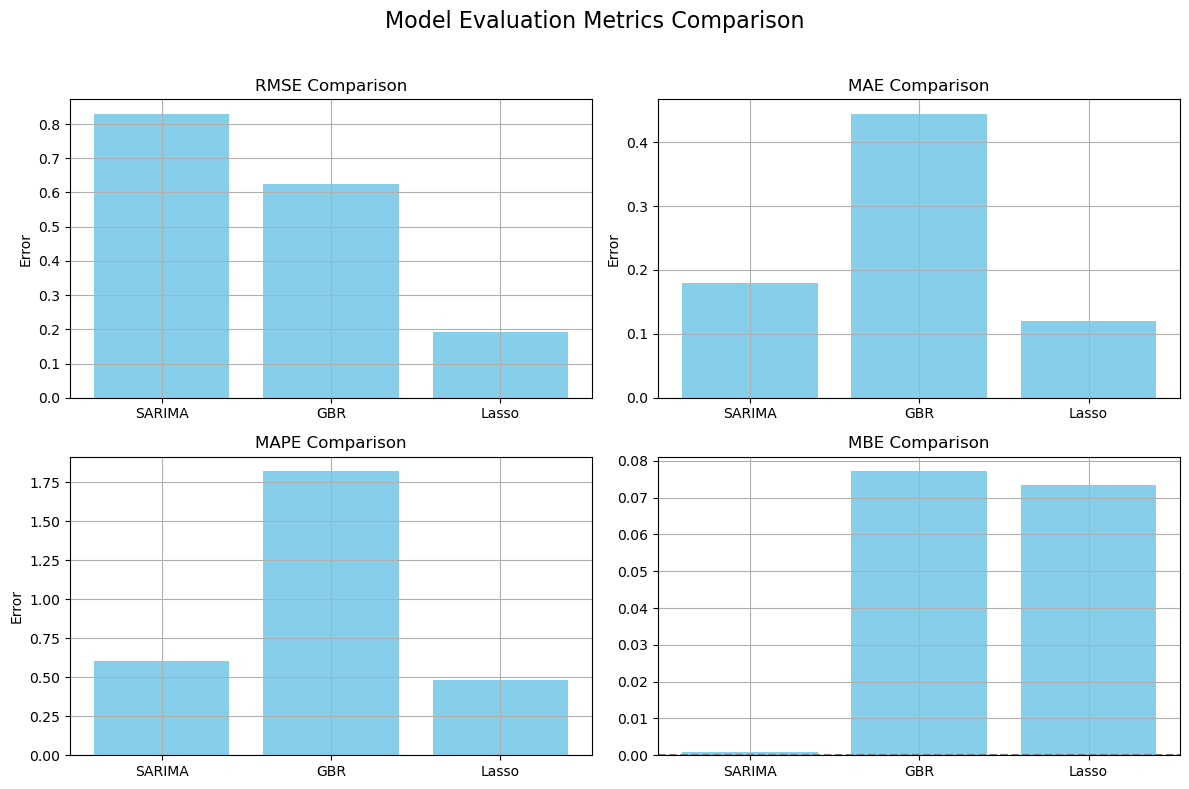

In [16]:
# Visualizing Model Performances for Comparison

# Compute evaluation metrics for all valid models
eval_df = pd.DataFrame({
    'Model': ['SARIMA', 'GBR', 'Lasso'],
    'RMSE': [
        np.sqrt(mean_squared_error(df['Emissions'], df['SARIMA_Forecast'])),
        np.sqrt(mean_squared_error(y_test, gbr_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred))
    ],
    'MAE': [
        mean_absolute_error(df['Emissions'], df['SARIMA_Forecast']),
        mean_absolute_error(y_test, gbr_pred),
        mean_absolute_error(y_test, lasso_pred)
    ],
    'MAPE': [
        np.mean(np.abs((df['Emissions'] - df['SARIMA_Forecast']) / df['Emissions'])) * 100,
        np.mean(np.abs((y_test - gbr_pred) / y_test)) * 100,
        np.mean(np.abs((y_test - lasso_pred) / y_test)) * 100
    ],
    'MBE': [
        np.mean(df['SARIMA_Forecast'] - df['Emissions']),
        np.mean(gbr_pred - y_test),
        np.mean(lasso_pred - y_test)
    ]
})

# Plot evaluation metrics
metrics = ['RMSE', 'MAE', 'MAPE', 'MBE']
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for ax, metric in zip(axs.flatten(), metrics):
    ax.bar(eval_df['Model'], eval_df[metric], color='skyblue')
    ax.set_title(f'{metric} Comparison')
    ax.grid(True)
    if metric in ['RMSE', 'MAE', 'MAPE']:
        ax.set_ylabel('Error')
    else:
        ax.axhline(0, color='gray', linestyle='--')  # Ideal baseline for MBE

plt.suptitle("Model Evaluation Metrics Comparison", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



## Post-Modelling EDA

- Actual vs Predicted Over Time
- Residuals Over Time
- SHAP Summary Plot
- Cumulative Forecast Error

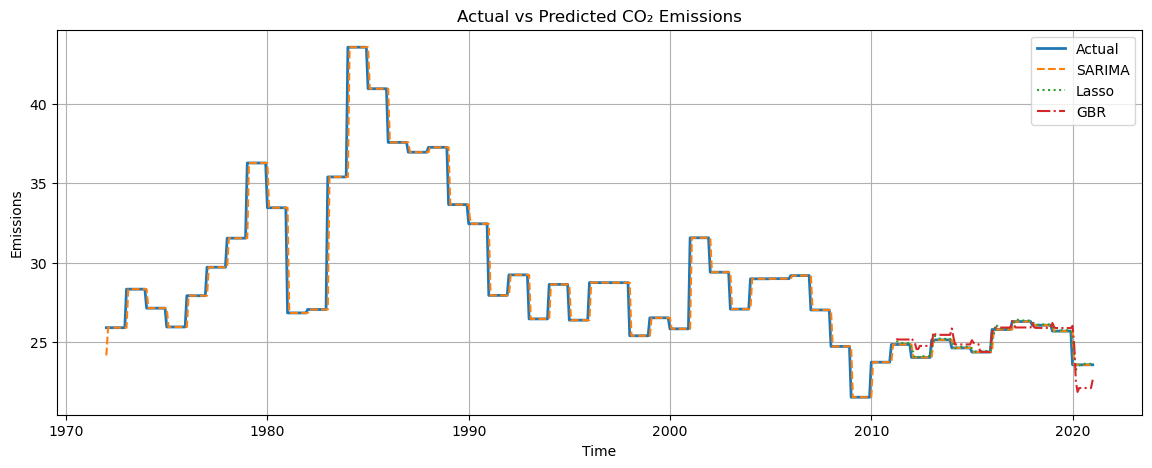

In [21]:
plt.figure(figsize=(14, 5))
plt.plot(df['Emissions'], label='Actual', linewidth=2)
plt.plot(df['SARIMA_Forecast'], label='SARIMA', linestyle='--')
plt.plot(y_test.index, lasso_pred, label='Lasso', linestyle=':')
plt.plot(y_test.index, gbr_pred, label='GBR', linestyle='-.')
plt.title("Actual vs Predicted CO₂ Emissions")
plt.xlabel("Time")
plt.ylabel("Emissions")
plt.legend()
plt.grid(True)
plt.show()

#### Observations: 
- All three models (SARIMA, Lasso, GBR) closely follow the actual CO₂ emissions values over time.
- From 1970 to ~2010, all models align very tightly with the observed emissions.
- Divergences become more visible from 2010 onward, with increasing variation in model behavior during 2019–2021.

#### Interpretation:
- The strong alignment over most of the historical period confirms that all models appropriately captured long-term temporal trends, including structural changes like the rise and fall of emissions in the 1980s and 2000s.
- Minimal early-model divergence suggests the time series is fairly smooth and lacks frequent structural breaks, supporting the use of models like SARIMA and regularized regression.
- Post-2010 deviations likely reflect real-world changes not captured in the models:
- Potential regulatory shifts, economic shocks, or COVID-19 disruptions starting ~2020.
- This is particularly relevant for GBR, which diverges more sharply — suggesting it reacts more to recent irregularities, whereas Lasso and SARIMA smooth over them.


#### Implication: 
- If future forecasting is a goal, these later divergences signal a need for updated or exogenous features (e.g., economic indicators, policy interventions) to improve model responsiveness during volatility.



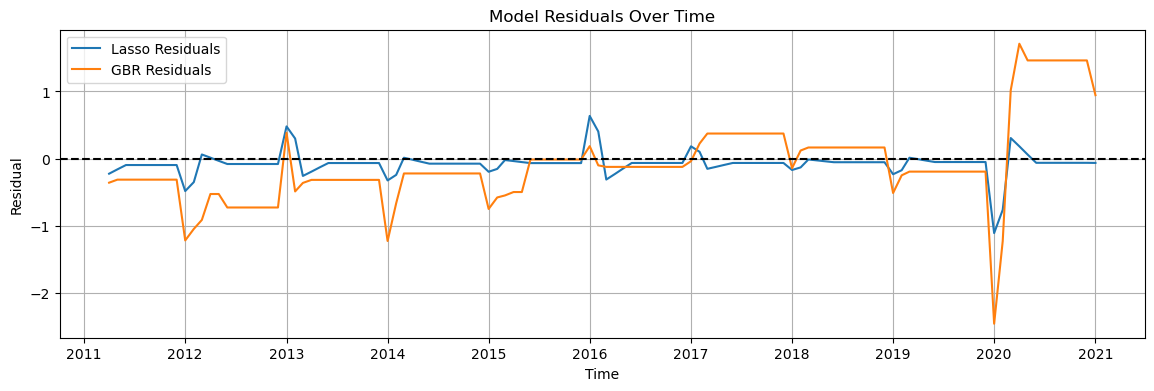

In [22]:
plt.figure(figsize=(14, 4))
plt.plot(y_test.index, resid_lasso, label='Lasso Residuals')
plt.plot(y_test.index, resid_gbr, label='GBR Residuals')
plt.axhline(0, color='black', linestyle='--')
plt.title("Model Residuals Over Time")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.legend()
plt.grid(True)
plt.show()


#### Observations
- The residuals (Actual − Predicted) for both Lasso and GBR are plotted from 2011 to 2021.
- Lasso residuals hover closely around zero with relatively small magnitude.
- GBR residuals show large, coherent deviations in specific periods:
- Underprediction from 2012–2015.
- Overprediction in 2020, underprediction shortly after.

#### Interpretation:
- Lasso’s behavior: This model is more stable — it minimizes average prediction error through L1 regularization, which shrinks less informative features and avoids overreacting to outliers. However, the plot reveals a mild negative trend, especially during 2016–2019, suggesting a subtle downward bias in predictions.
- GBR’s behavior: Gradient Boosting is highly flexible and nonlinear, which gives it stronger expressive power — but also greater risk of overfitting to noise or local fluctuations. This is visible in:
- Systematic underprediction early on (2012–2015), possibly due to missing long-term memory or feature misalignment.
- Overprediction spike in 2020, aligning with what may have been an emissions drop due to COVID-19.

#### Implication: 
- While GBR captures fine-grained dynamics better, it sacrifices stability. These findings support using ensemble averaging or hybrid modeling if forecast stability is critical.

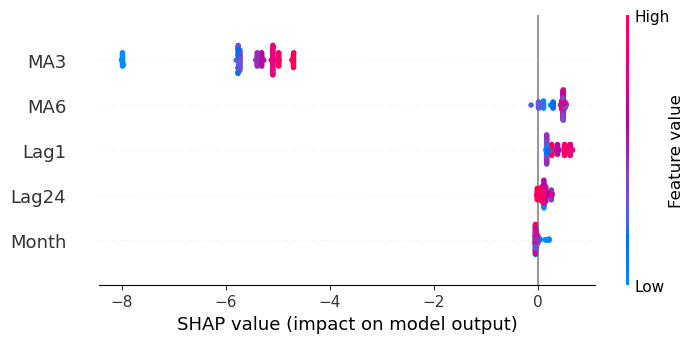

In [23]:
explainer = shap.Explainer(gbr)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)


#### SHAP Overview
- SHAP values explain the impact of each feature on the GBR model’s output.

#### Features:
- MA3, MA6: Moving averages over 3 and 6 months
- Lag1, Lag24: Lagged values (1 month and 24 months back)
- Month: Categorical or cyclical indicator
- MA3 and MA6 are the most impactful and negatively associated with emissions predictions.

#### Interpretation:
- The dominance of MA3 and MA6 implies that the model relies heavily on short-term trends to forecast emissions. Increases in these moving averages (higher recent emissions) tend to pull predictions down, possibly reflecting the model’s learned tendency that emission spikes are followed by corrections.
- The effect of Lag1 is minimal and inconsistently signed — suggesting little short-term autocorrelation not already captured by moving averages.
- Lag24 (2-year lag) has modest positive influence — this might hint at some long-term periodicity, but it's weaker than local momentum features.
- The insignificance of Month confirms that seasonality is not a major driver in industrial CO₂ emissions, likely because industrial processes are not tightly linked to seasons.

#### Implication:
- The model’s structure implicitly confirms that emissions dynamics are smoother and trend-dominated, rather than periodic or seasonal.
- Feature engineering should focus on trend-capturing features (e.g., MA, cumulative lags) over calendar-based variables.

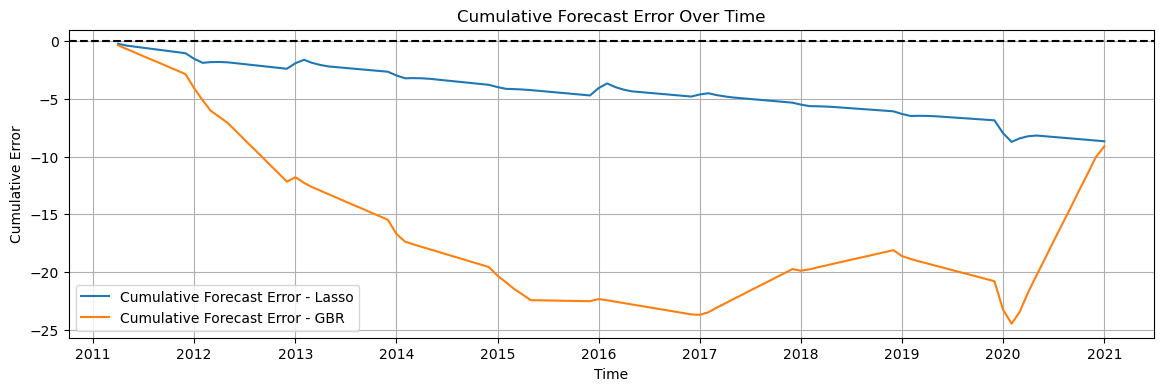

In [24]:
cfe_lasso = resid_lasso.cumsum()
cfe_gbr = resid_gbr.cumsum()

plt.figure(figsize=(14, 4))
plt.plot(cfe_lasso, label='Cumulative Forecast Error - Lasso')
plt.plot(cfe_gbr, label='Cumulative Forecast Error - GBR')
plt.axhline(0, color='black', linestyle='--')
plt.title("Cumulative Forecast Error Over Time")
plt.ylabel("Cumulative Error")
plt.xlabel("Time")
plt.legend()
plt.grid(True)
plt.show()

#### Observations
- Cumulative sum of residuals (Sum of (Actual − Predicted)) over time.
- Lasso shows a smooth, gradual downward slope.
- GBR shows a steep cumulative decline through ~2016, then sharp changes in slope during 2020–2021.

#### Interpretation:
- Lasso accumulates a moderate but persistent negative error → suggests consistent underprediction of emissions. Because this is gradual and linear, the issue likely stems from its systematic bias introduced by shrinkage.
- GBR starts off accumulating error rapidly, then partially corrects and levels off, before spiking again during 2019–2021.
- The sharp drop in 2020 matches known disruptions (e.g., COVID-19-related shifts in energy usage or reporting).
- The partial correction in 2021 suggests the model is flexible but also erratic in highly volatile periods.

#### Implication:
The cumulative error behavior reveals that:
- Lasso is more stable, but misaligned on level calibration.
- GBR is reactive, better at capturing shocks but vulnerable to noise.
- The plot supports the idea that combining models (e.g., SARIMA + Lasso) or adopting post-correction layers (e.g., residual learning) might improve robustness.

## Best Performing Model (Lasso)

In [27]:
import pandas as pd

# If X_train is a DataFrame, extract column names
feature_names = X_train.columns if isinstance(X_train, pd.DataFrame) else [f"X{i}" for i in range(X_train.shape[1])]

# Build a DataFrame linking predictors to coefficients
lasso_summary = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso.coef_
})

# Filter out dropped (zero) coefficients
lasso_summary = lasso_summary[lasso_summary['Coefficient'] != 0]

# Sort by absolute impact
lasso_summary['AbsCoeff'] = lasso_summary['Coefficient'].abs()
lasso_summary.sort_values(by='AbsCoeff', ascending=False, inplace=True)
lasso_summary.drop(columns='AbsCoeff', inplace=True)

# Show result
print(lasso_summary)


  Feature  Coefficient
2     MA3     7.930207
3     MA6    -1.619492
0    Lag1    -1.616759
1   Lag24    -0.039684


In [31]:
# Intercept
print("Lasso intercept is: ",lasso.intercept_)

# Optimal regularization parameter
print("Lasso regularization parameter is: ",lasso.alpha_)

Lasso intercept is:  29.814083757961786
Lasso regularization parameter is:  0.0047010621663848015
